In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

f:\Desktop\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


#### Langgraph blogs database retreiver

In [3]:
urls = ["https://langchain-ai.github.io/langgraph/tutorials/introduction/",
        "https://langchain-ai.github.io/langgraph/tutorials/",
        "https://langchain-ai.github.io/langgraph/how-tos/",
        "https://langchain-ai.github.io/langgraph/reference/"]

In [4]:
docs = [WebBaseLoader(url).load() for url in urls]

In [5]:
# get the information
doc_list = [doc for sublist in docs for doc in sublist]
print(doc_list)

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='\n\n\n\nRedirecting...\n\n\n\n\n\n\nRedirecting...\n\n\n'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='\n\n\n\nRedirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...\n\n\n'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='\n\n\n\nRedirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...\n\n\n'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/reference/', 'title

In [6]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
split_docs = text_splitter.split_documents(doc_list)
print(split_docs)

[Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='Redirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='Redirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...'), Document(metadata={'source': 'https://langchain-ai.github.io/langgraph/reference/', 'title': 'Redirecting...', 'language': 'en'}, pa

In [7]:
vectorestore = FAISS.from_documents(documents = split_docs,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"))

retriever = vectorestore.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2976.69it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
retriever.invoke("What is TypeDictState?")

[Document(id='8823c6cf-3454-47c3-89ae-9ad3376a161b', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='Redirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...'),
 Document(id='c550fa79-4df5-44d5-8012-90b6ce53f449', metadata={'source': 'https://langchain-ai.github.io/langgraph/how-tos/', 'title': 'Redirecting to LangGraph Documentation', 'language': 'en'}, page_content='Redirecting to LangGraph Documentation\n\n\n\n\n\n\nDocumentation has moved\nThe LangGraph documentation has moved to docs.langchain.com.\nRedirecting you now...'),
 Document(id='19fb2a9f-9192-472b-8c36-6a00b6d983fc', metadata={'source': 'https://langchain-ai.github.io/langgraph/tutorials/introduction/', 'title': 'Redirecting...', 'language': 'en'}, page_content='Redirecting...\n\n\n\n\n\n\nRedirecting...'),
 

In [9]:
# retriever to retreiver tool
from langchain_core.tools.retriever import create_retriever_tool
retreiver_tool = create_retriever_tool(retriever=retriever,name = "retriever_vector_db_blog",description="Search and run information about langgraph")

In [10]:
print(retreiver_tool)

name='retriever_vector_db_blog' description='Search and run information about langgraph' args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'> func=<function create_retriever_tool.<locals>.func at 0x00000151A0AA0860> coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000151A0AA0AE0>


#### Langchain blogs database retreiver

In [11]:
urls = [
    "https://python.langchain.com/docs/get_started/introduction/",
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/how_to/"
]

In [12]:
docs = [WebBaseLoader(url).load() for url in urls]

In [13]:
docs_list = [doc for sublist in docs for doc in sublist]

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
split_docs = text_splitter.split_documents(doc_list)
vectorstorelangchain = FAISS.from_documents(documents=split_docs,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"))
retreiverlangchain = vectorstorelangchain.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6454.57it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
retreiver_langchain_tool = create_retriever_tool(retriever=retreiverlangchain,name = "retreiver_vector_langchain_db",description="Search and run information about langchain")

In [15]:
tools = [retreiver_tool, retreiver_langchain_tool]

In [16]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict,Literal
from langchain_core.messages import BaseMessage,AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

In [17]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.1-8b-instant",api_key=groq_api_key)

In [18]:
def agent(state:AgentState):
    """ It invokes the agent model to generate a response based on the current state. Given the question, It will
    decide to retrieve using the retriever tool, or simply end.
    Args:
    state(messages): the current state
    
    Returns: dict: The updated state with the agent response appended to messages"""
    print("---CALLING AGENT---")
    messages = state["messages"]
    AgentModel = ChatGroq(model_name = "llama-3.1-8b-instant")
    AgentModel = AgentModel.bind_tools(tools)
    response = AgentModel.invoke(messages)
    return{"messages":[response]}

In [19]:
from pydantic import BaseModel,Field
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

class grade(BaseModel):
    """Binary scores for relevance check."""
    binary_score:str = Field(description="Relevance score 'Yes' or 'No' ")

def grade_documents(state:AgentState)-> Literal["Generate","Rewrite"]:
    """ Determines whether the retrieved documents are relavant to the question
    
    Args:
        state(messages): the current state
        
    Returns: 
        str: A decision for whether the documents are relavant or not
        """
    
    print("---CHECK RELEVANCE---")


    model = ChatGroq(model_name = "llama-3.1-8b-instant",api_key = groq_api_key)
    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template= """ You are a grader assessing relevance of a retreived documents to a user question. \n
        here is the retrieved documents: \n \n {context} \n\n
        here is the user question: {question} \n
        If the document contains Keyword(s) or semantic meaning related to the user question, grade it is a relevant. \n
        Give the binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables = ["context","question"]
    )

    # chain
    chain = prompt | llm_with_tool
    messages = state["messages"]

    question = messages[0].content

    last_message = messages[-1]
    docs = last_message.content

    scored_result = chain.invoke({"question":question,"context":docs})

    score = scored_result.binary_score

    if score == "Yes":
        print("---Decision: DOCS RELEVANT---")
        return "Generate"
    else:
        print("---DOCS NOT RELEVANT---")
        return "Rewrite"

In [20]:
from langchain_classic import hub
def generate(state:AgentState):
    """Generate answer
    
    Args:
        state(messages): The current state
    
    returns:
        dict: The updated message
    """
    
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content

    prompt = hub.pull("rlm/rag-prompt")

    llm = ChatGroq(model_name = "llama-3.1-8b-instant",api_key = groq_api_key)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    response_answer = rag_chain.invoke({"question":question,"context":docs})
    return {"messages":[response_answer]}

In [21]:
from langchain_core.messages import HumanMessage
def rewrite(state:AgentState):
    """ Transform the query to produce a better question.
    Args:
        state(messages): the current state
        
    returns:
        dict: the updated state with re-phrased question
    """
    print("---TRANSFORM QUERY---")

    messages = state["messages"]
    question = messages[0].content

    msg = [HumanMessage(content=""" \n
Look at the input and try to reason about the underlyig semantic intent / meaning. \n
Here is the initial question:
\n ----- \n                        
{question}
\n ----- \n
Formulate an improved question:""")]
    
    model = ChatGroq(model_name = "llama-3.1-8b-instant",api_key = groq_api_key)

    model.invoke(msg)

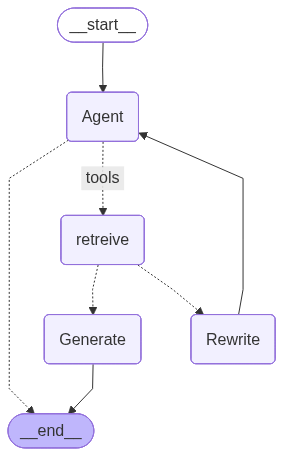

In [22]:
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
graph = StateGraph(AgentState)

graph.add_node("Agent",agent)
retreive = ToolNode([retreiver_tool, retreiver_langchain_tool])
graph.add_node("retreive",retreive)
graph.add_node("Rewrite",rewrite)
graph.add_node("Generate",generate)

# adding the edges
graph.add_edge(START,"Agent")
graph.add_conditional_edges("Agent",tools_condition,{"tools":"retreive",END:END})

graph.add_conditional_edges("retreive",grade_documents,{"Generate":"Generate","Rewrite":"Rewrite"})

graph.add_edge("Rewrite","Agent")
graph.add_edge("Generate",END)

graph_builder = graph.compile()
visualization_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualization_graph))



In [23]:
messages = graph_builder.invoke({"messages":"What is machine learning?"})
print(messages["messages"][-1].content)


---CALLING AGENT---
---CHECK RELEVANCE---
---DOCS NOT RELEVANT---
---TRANSFORM QUERY---
---CALLING AGENT---
---CHECK RELEVANCE---
---DOCS NOT RELEVANT---
---TRANSFORM QUERY---
---CALLING AGENT---
It appears that there was a redirect loop.
